In [9]:
!pip install -q openslide-bin openslide-python opencv-python-headless

**Import libraries**

In [10]:
import os
import gc
import zipfile
import random
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

import openslide

In [11]:
from pathlib import Path

print("Files/folders inside /kaggle/input:")

for p in Path("/kaggle/input").iterdir():
    print(p)

Files/folders inside /kaggle/input:
/kaggle/input/competitions


In [12]:
from pathlib import Path

COMPETITIONS_ROOT = Path("/kaggle/input/competitions")

print("Competition directory exists:", COMPETITIONS_ROOT.exists())

print("\nContents:")
for item in COMPETITIONS_ROOT.iterdir():
    print(item)

Competition directory exists: True

Contents:
/kaggle/input/competitions/prostate-cancer-grade-assessment


In [13]:
from pathlib import Path

DATA_ROOT = Path(
    "/kaggle/input/competitions/prostate-cancer-grade-assessment"
)

print("Dataset exists:", DATA_ROOT.exists())

Dataset exists: True


In [14]:
print("PANDA dataset contents:\n")

for item in DATA_ROOT.iterdir():
    print(item)

PANDA dataset contents:

/kaggle/input/competitions/prostate-cancer-grade-assessment/sample_submission.csv
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_label_masks
/kaggle/input/competitions/prostate-cancer-grade-assessment/train.csv
/kaggle/input/competitions/prostate-cancer-grade-assessment/test.csv


In [15]:
all_files = list(DATA_ROOT.rglob("*"))

print("Total files/folders:", len(all_files))

for item in all_files[:100]:
    print(item)

Total files/folders: 21137
/kaggle/input/competitions/prostate-cancer-grade-assessment/sample_submission.csv
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_label_masks
/kaggle/input/competitions/prostate-cancer-grade-assessment/train.csv
/kaggle/input/competitions/prostate-cancer-grade-assessment/test.csv
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/825c6002ff3ab0e041ebd7025ba41b4f.tiff
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/45d0ddf0aeb9b7f3c8e6c19c4405ac99.tiff
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/ae8f2e2b28764a604d1acc4bd7c8feb7.tiff
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/11a715facad7b619e3213ce126be1c77.tiff
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/4ecad8aefbc2ce6931baaee0cda6955b.tiff
/kaggle/input/competitions/prostate-cancer-gra

In [16]:
from pathlib import Path

# PANDA dataset
DATA_ROOT = Path(
    "/kaggle/input/competitions/prostate-cancer-grade-assessment"
)

# Important folders
TRAIN_IMAGES = DATA_ROOT / "train_images"
TRAIN_MASKS = DATA_ROOT / "train_label_masks"

# Metadata
TRAIN_CSV = DATA_ROOT / "train.csv"
TEST_CSV = DATA_ROOT / "test.csv"

print("Dataset:", DATA_ROOT.exists())
print("Images:", TRAIN_IMAGES.exists())
print("Masks:", TRAIN_MASKS.exists())
print("Train CSV:", TRAIN_CSV.exists())
print("Test CSV:", TEST_CSV.exists())

Dataset: True
Images: True
Masks: True
Train CSV: True
Test CSV: True


In [17]:
import pandas as pd

train_df = pd.read_csv(TRAIN_CSV)

print("Shape:", train_df.shape)

display(train_df.head())

Shape: (10616, 4)


,image_id,data_provider,isup_grade,gleason_score
0,0005f7aaab2800f6170c399693a96917,karolinska,0,0+0
1,000920ad0b612851f8e01bcc880d9b3d,karolinska,0,0+0
2,0018ae58b01bdadc8e347995b69f99aa,radboud,4,4+4
3,001c62abd11fa4b57bf7a6c603a11bb9,karolinska,4,4+4
4,001d865e65ef5d2579c190a0e0350d8f,karolinska,0,0+0


In [18]:
print("Columns:")

for column in train_df.columns:
    print("-", column)

Columns:
- image_id
- data_provider
- isup_grade
- gleason_score


In [19]:
print("\nData types:")
print(train_df.dtypes)


Data types:
image_id         object
data_provider    object
isup_grade        int64
gleason_score    object
dtype: object


In [20]:
missing = train_df.isnull().sum()

display(
    missing[missing > 0]
)

Series([], dtype: int64)

In [21]:
[c for c in train_df.columns if "isup" in c.lower()]

['isup_grade']

In [22]:
[c for c in train_df.columns if "gleason" in c.lower()]

['gleason_score']

In [23]:
slide_files = list(TRAIN_IMAGES.glob("*.tiff"))

print("Number of WSI files:", len(slide_files))

Number of WSI files: 10616


In [24]:
print("First 10 slides:")

for slide_path in slide_files[:10]:
    print(slide_path.name)

First 10 slides:
825c6002ff3ab0e041ebd7025ba41b4f.tiff
45d0ddf0aeb9b7f3c8e6c19c4405ac99.tiff
ae8f2e2b28764a604d1acc4bd7c8feb7.tiff
11a715facad7b619e3213ce126be1c77.tiff
4ecad8aefbc2ce6931baaee0cda6955b.tiff
136cae2844e9f6fd15f09ccc9453e0b6.tiff
a112bfd9f4a972330c8fddf14477e458.tiff
c7b8b5d4f033d38b29c52d363b0bc7dc.tiff
cbb06f8997eccd33dc7fc6562f2e06fb.tiff
9fa0924e247810df3f2563454dc82884.tiff


In [25]:
first_slide = slide_files[0]

print("File:", first_slide.name)

slide_id = first_slide.stem

print("Slide ID:", slide_id)

File: 825c6002ff3ab0e041ebd7025ba41b4f.tiff
Slide ID: 825c6002ff3ab0e041ebd7025ba41b4f


In [26]:
print(
    train_df[train_df["image_id"] == slide_id]
)

                              image_id data_provider  isup_grade gleason_score
5265  825c6002ff3ab0e041ebd7025ba41b4f       radboud           0      negative


In [27]:
import openslide
import numpy as np
import matplotlib.pyplot as plt

slide = openslide.OpenSlide(
    str(first_slide)
)

print("WSI dimensions:", slide.dimensions)
print("Number of levels:", slide.level_count)

for level in range(slide.level_count):
    print(
        f"Level {level}:",
        slide.level_dimensions[level],
        "Downsample:",
        slide.level_downsamples[level]
    )

WSI dimensions: (9728, 29440)
Number of levels: 3
Level 0: (9728, 29440) Downsample: 1.0
Level 1: (2432, 7360) Downsample: 4.0
Level 2: (608, 1840) Downsample: 16.0


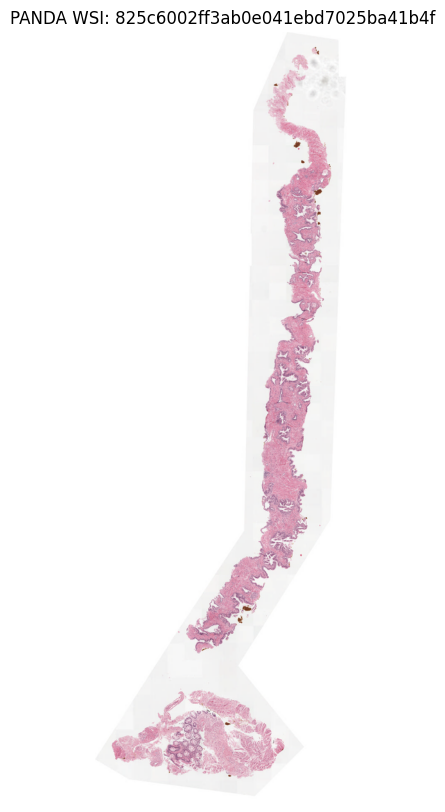

In [28]:
thumbnail = slide.get_thumbnail((1200, 1200))

plt.figure(figsize=(10, 10))

plt.imshow(thumbnail)

plt.axis("off")

plt.title(
    f"PANDA WSI: {slide_id}"
)

plt.show()

In [29]:
thumbnail_np = np.array(thumbnail)

print("Thumbnail shape:", thumbnail_np.shape)
print("Data type:", thumbnail_np.dtype)

Thumbnail shape: (1200, 397, 3)
Data type: uint8


In [30]:
import cv2

hsv = cv2.cvtColor(
    thumbnail_np,
    cv2.COLOR_RGB2HSV
)

saturation = hsv[:, :, 1]

print("Saturation shape:", saturation.shape)

Saturation shape: (1200, 397)


In [31]:
otsu_threshold, tissue_mask = cv2.threshold(
    saturation,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold:", otsu_threshold)

Otsu threshold: 33.0


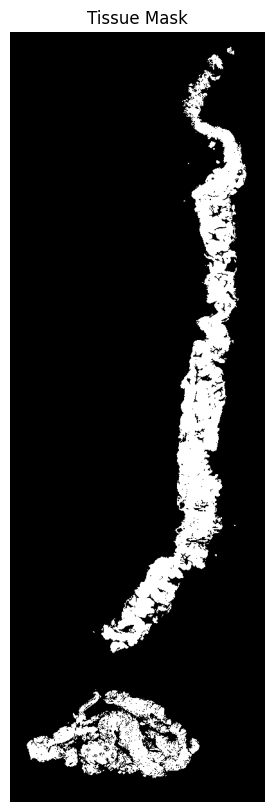

In [32]:
plt.figure(figsize=(10, 10))

plt.imshow(
    tissue_mask,
    cmap="gray"
)

plt.axis("off")

plt.title("Tissue Mask")

plt.show()

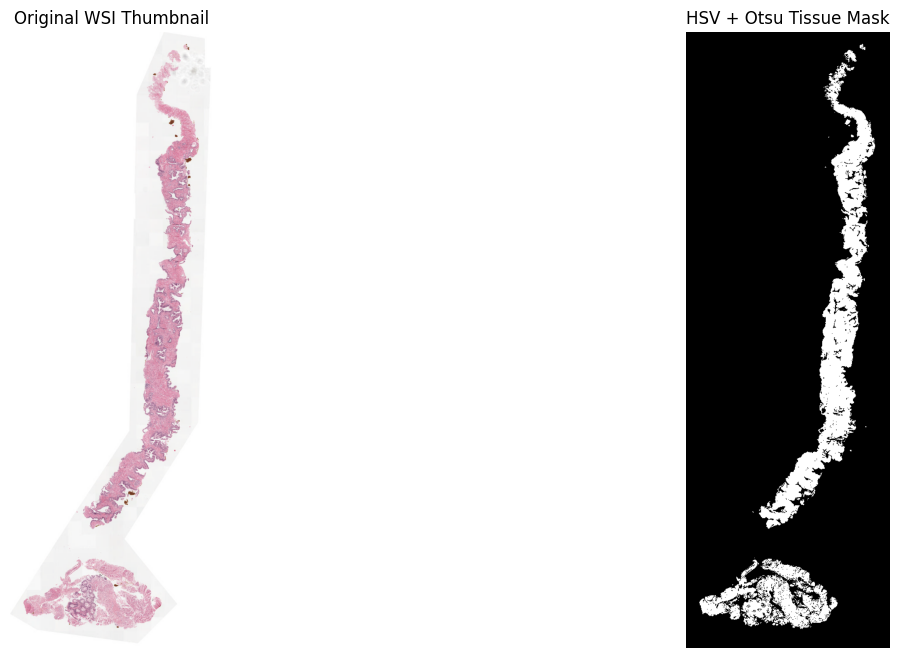

In [33]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 8)
)

axes[0].imshow(thumbnail_np)
axes[0].set_title("Original WSI Thumbnail")
axes[0].axis("off")

axes[1].imshow(tissue_mask, cmap="gray")
axes[1].set_title("HSV + Otsu Tissue Mask")
axes[1].axis("off")

plt.show()

In [34]:
display(train_df.head())

,image_id,data_provider,isup_grade,gleason_score
0,0005f7aaab2800f6170c399693a96917,karolinska,0,0+0
1,000920ad0b612851f8e01bcc880d9b3d,karolinska,0,0+0
2,0018ae58b01bdadc8e347995b69f99aa,radboud,4,4+4
3,001c62abd11fa4b57bf7a6c603a11bb9,karolinska,4,4+4
4,001d865e65ef5d2579c190a0e0350d8f,karolinska,0,0+0


In [35]:
print(train_df.columns.tolist())

['image_id', 'data_provider', 'isup_grade', 'gleason_score']


In [36]:
from pathlib import Path

mask_files = list(TRAIN_MASKS.glob("*"))

print("Number of mask files:", len(mask_files))

print("\nFirst 20 mask files:")
for f in mask_files[:20]:
    print(f.name)

Number of mask files: 10516

First 20 mask files:
c699f572c40dbee492ca9ac0c1a0d9f7_mask.tiff
78138d4fc0b8fceb04138cd44d4a4fdd_mask.tiff
8bf80024b1a7f12ce52136af81a930df_mask.tiff
b4f3528c1ab8e7ae2faac094cdbe06c3_mask.tiff
1abb6882a5cba3d9c166736825bbe101_mask.tiff
67221cc31ec6ad9e106de548f7aa5823_mask.tiff
f5d72b1f141a139c46446d263ceb5e7c_mask.tiff
ff0f8705f77b14b2a84b498933adf18a_mask.tiff
f526a2ca5612d5913984a67edabaf991_mask.tiff
e173f2b10faccbb5c9f5a0c38a2a1fd0_mask.tiff
f750891191013386453c29c16670e951_mask.tiff
1d33889037497d32695ac48a786af6d5_mask.tiff
0a5d6a20d1429dd55b94ae1b857ad573_mask.tiff
793a0289643d24429d30f07b32b4204c_mask.tiff
89d9673df0dede5b57c52f98b43c1f9e_mask.tiff
78c7bad2262ae25179e8cd6633648487_mask.tiff
77de0e765d8729e7386589f21961279f_mask.tiff
382ddc25ec205c031a76956d6060bd2b_mask.tiff
c982dc4f74dcfac91002598931c0b726_mask.tiff
15a6a06636e0bb96ad2703a64d06fcfc_mask.tiff


In [37]:
print("WSI files :", len(slide_files))
print("Mask files:", len(mask_files))
print("CSV rows  :", len(train_df))

WSI files : 10616
Mask files: 10516
CSV rows  : 10616


In [38]:
sample_id = train_df.iloc[0]["image_id"]

print("Sample image ID:", sample_id)

Sample image ID: 0005f7aaab2800f6170c399693a96917


In [39]:
sample_image = TRAIN_IMAGES / f"{sample_id}.tiff"

print("Image path:")
print(sample_image)

print("Exists:", sample_image.exists())

Image path:
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/0005f7aaab2800f6170c399693a96917.tiff
Exists: True


In [40]:
sample_masks = list(
    TRAIN_MASKS.glob(f"{sample_id}.*")
)

print("Matching masks:")

for m in sample_masks:
    print(m)

Matching masks:


In [41]:
# Inspect the actual mask directory

print("Mask directory:")
print(TRAIN_MASKS)

print("\nNumber of files/folders:")
print(len(list(TRAIN_MASKS.iterdir())))

print("\nFirst 30 items:")

for item in list(TRAIN_MASKS.iterdir())[:30]:
    print(item.name)

Mask directory:
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_label_masks

Number of files/folders:
10516

First 30 items:
c699f572c40dbee492ca9ac0c1a0d9f7_mask.tiff
78138d4fc0b8fceb04138cd44d4a4fdd_mask.tiff
8bf80024b1a7f12ce52136af81a930df_mask.tiff
b4f3528c1ab8e7ae2faac094cdbe06c3_mask.tiff
1abb6882a5cba3d9c166736825bbe101_mask.tiff
67221cc31ec6ad9e106de548f7aa5823_mask.tiff
f5d72b1f141a139c46446d263ceb5e7c_mask.tiff
ff0f8705f77b14b2a84b498933adf18a_mask.tiff
f526a2ca5612d5913984a67edabaf991_mask.tiff
e173f2b10faccbb5c9f5a0c38a2a1fd0_mask.tiff
f750891191013386453c29c16670e951_mask.tiff
1d33889037497d32695ac48a786af6d5_mask.tiff
0a5d6a20d1429dd55b94ae1b857ad573_mask.tiff
793a0289643d24429d30f07b32b4204c_mask.tiff
89d9673df0dede5b57c52f98b43c1f9e_mask.tiff
78c7bad2262ae25179e8cd6633648487_mask.tiff
77de0e765d8729e7386589f21961279f_mask.tiff
382ddc25ec205c031a76956d6060bd2b_mask.tiff
c982dc4f74dcfac91002598931c0b726_mask.tiff
15a6a06636e0bb96ad2703a64d06fcfc_mask.ti

In [42]:
# Check the file extensions actually used

from collections import Counter

mask_items = list(TRAIN_MASKS.iterdir())

extensions = Counter(
    item.suffix.lower()
    for item in mask_items
    if item.is_file()
)

print("Mask file extensions:")
print(extensions)

Mask file extensions:
Counter({'.tiff': 10516})


In [43]:
# Show files containing our sample ID

print("Sample ID:")
print(sample_id)

print("\nPossible matching files:")

matches = []

for item in TRAIN_MASKS.rglob("*"):
    if item.is_file() and sample_id in item.name:
        matches.append(item)

for item in matches[:30]:
    print(item)

print("\nNumber of matches:", len(matches))

Sample ID:
0005f7aaab2800f6170c399693a96917

Possible matching files:
/kaggle/input/competitions/prostate-cancer-grade-assessment/train_label_masks/0005f7aaab2800f6170c399693a96917_mask.tiff

Number of matches: 1


In [44]:
# Get the sample WSI
sample_id = train_df.iloc[0]["image_id"]

# WSI path
wsi_path = TRAIN_IMAGES / f"{sample_id}.tiff"

# Mask path
mask_path = TRAIN_MASKS / f"{sample_id}_mask.tiff"

print("Sample ID:", sample_id)
print("WSI path:", wsi_path)
print("Mask path:", mask_path)

print("\nWSI exists:", wsi_path.exists())
print("Mask exists:", mask_path.exists())

Sample ID: 0005f7aaab2800f6170c399693a96917
WSI path: /kaggle/input/competitions/prostate-cancer-grade-assessment/train_images/0005f7aaab2800f6170c399693a96917.tiff
Mask path: /kaggle/input/competitions/prostate-cancer-grade-assessment/train_label_masks/0005f7aaab2800f6170c399693a96917_mask.tiff

WSI exists: True
Mask exists: True


In [45]:
import openslide
import tifffile

# Open WSI
slide = openslide.OpenSlide(str(wsi_path))

print("===== WSI =====")
print("WSI dimensions:", slide.dimensions)
print("WSI levels:", slide.level_count)
print("WSI level dimensions:", slide.level_dimensions)

print("\n===== MASK =====")

# Read only TIFF metadata
with tifffile.TiffFile(str(mask_path)) as tif:
    page = tif.pages[0]

    print("Mask dimensions:", page.shape)
    print("Mask dtype:", page.dtype)
    print("Mask axes:", page.axes)
    print("Mask compression:", page.compression)
    print("Number of TIFF pages:", len(tif.pages))

===== WSI =====
WSI dimensions: (27648, 29440)
WSI levels: 3
WSI level dimensions: ((27648, 29440), (6912, 7360), (1728, 1840))

===== MASK =====
Mask dimensions: (29440, 27648, 3)
Mask dtype: uint8
Mask axes: YXS
Mask compression: 5
Number of TIFF pages: 3


In [46]:
import importlib.util

print("imagecodecs available:",
      importlib.util.find_spec("imagecodecs") is not None)

imagecodecs available: False


In [47]:
import tifffile

with tifffile.TiffFile(str(mask_path)) as tif:
    page = tif.pages[0]

    print("Shape:", page.shape)
    print("Dtype:", page.dtype)
    print("Compression:", page.compression)
    print("Compression name:", page.compression.name)

    print("\nNumber of strips:", len(page.dataoffsets))
    print("First 10 data offsets:")
    print(page.dataoffsets[:10])

    print("\nFirst 10 byte counts:")
    print(page.databytecounts[:10])

Shape: (29440, 27648, 3)
Dtype: uint8
Compression: 5
Compression name: LZW

Number of strips: 3132
First 10 data offsets:
(16, 1616, 3216, 4816, 6416, 8016, 9616, 11216, 12816, 14416)

First 10 byte counts:
(1600, 1600, 1600, 1600, 1600, 1600, 1600, 1600, 1600, 1600)


In [48]:
import importlib.util

packages = [
    "cv2",
    "PIL",
    "tifffile",
    "rasterio",
    "skimage",
    "imagecodecs",
    "openslide",
]

for pkg in packages:
    print(f"{pkg:12} :", importlib.util.find_spec(pkg) is not None)

cv2          : True
PIL          : True
tifffile     : True
rasterio     : True
skimage      : True
imagecodecs  : False
openslide    : True


In [49]:
import rasterio

with rasterio.open(mask_path) as src:
    print("Driver:", src.driver)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Bands:", src.count)
    print("Dtype:", src.dtypes)
    print("Compression:", src.compression)

Driver: GTiff
Width: 27648
Height: 29440
Bands: 3
Dtype: ('uint8', 'uint8', 'uint8')
Compression: Compression.lzw


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [50]:
import rasterio
import numpy as np

with rasterio.open(mask_path) as src:
    # Read the top-left 256 × 256 region
    sample_region = src.read(
        window=((0, 256), (0, 256))
    )

print("Raw shape:", sample_region.shape)
print("Dtype:", sample_region.dtype)

# Rasterio returns:
# (bands, height, width)
# Convert to:
# (height, width, bands)
sample_region = np.transpose(sample_region, (1, 2, 0))

print("RGB shape:", sample_region.shape)

print("\nMinimum value:", sample_region.min())
print("Maximum value:", sample_region.max())

# Find unique RGB colors
colors = np.unique(
    sample_region.reshape(-1, 3),
    axis=0
)

print("\nNumber of unique colors:", len(colors))
print("\nFirst 30 unique colors:")
print(colors[:30])

Raw shape: (3, 256, 256)
Dtype: uint8
RGB shape: (256, 256, 3)

Minimum value: 0
Maximum value: 0

Number of unique colors: 1

First 30 unique colors:
[[0 0 0]]


In [51]:
import rasterio
import numpy as np

# Different locations across the slide
windows = {
    "top_left":      (0, 0),
    "top_right":     (0, 27392),
    "middle":        (14592, 13696),
    "bottom_left":   (29184, 0),
    "bottom_right":  (29184, 27392),
}

with rasterio.open(mask_path) as src:

    for name, (row, col) in windows.items():

        region = src.read(
            window=((row, row + 256), (col, col + 256))
        )

        # Convert (bands, H, W) → (H, W, bands)
        region = np.transpose(region, (1, 2, 0))

        colors = np.unique(
            region.reshape(-1, 3),
            axis=0
        )

        print(f"\n===== {name} =====")
        print("Position:", (row, col))
        print("Shape:", region.shape)
        print("Min:", region.min())
        print("Max:", region.max())
        print("Unique colors:", len(colors))
        print("First colors:", colors[:10])


===== top_left =====
Position: (0, 0)
Shape: (256, 256, 3)
Min: 0
Max: 0
Unique colors: 1
First colors: [[0 0 0]]

===== top_right =====
Position: (0, 27392)
Shape: (256, 256, 3)
Min: 0
Max: 0
Unique colors: 1
First colors: [[0 0 0]]

===== middle =====
Position: (14592, 13696)
Shape: (256, 256, 3)
Min: 0
Max: 0
Unique colors: 1
First colors: [[0 0 0]]

===== bottom_left =====
Position: (29184, 0)
Shape: (256, 256, 3)
Min: 0
Max: 0
Unique colors: 1
First colors: [[0 0 0]]

===== bottom_right =====
Position: (29184, 27392)
Shape: (256, 256, 3)
Min: 0
Max: 0
Unique colors: 1
First colors: [[0 0 0]]


In [52]:
import rasterio
import numpy as np

with rasterio.open(mask_path) as src:

    # Read the whole mask but resample directly to a tiny overview
    overview = src.read(
        out_shape=(3, 256, 256),
        resampling=rasterio.enums.Resampling.nearest
    )

print("Overview shape:", overview.shape)
print("Dtype:", overview.dtype)

print("Global minimum:", overview.min())
print("Global maximum:", overview.max())

# Convert to H x W x 3
overview_rgb = np.transpose(overview, (1, 2, 0))

# Unique colors in the small overview
colors = np.unique(
    overview_rgb.reshape(-1, 3),
    axis=0
)

print("Number of unique colors:", len(colors))
print("\nFirst 30 colors:")
print(colors[:30])

# Count non-zero pixels
nonzero_pixels = np.any(overview_rgb != 0, axis=2)

print("\nNon-zero pixels:", nonzero_pixels.sum())
print("Total pixels:", nonzero_pixels.size)
print(
    "Non-zero percentage:",
    100 * nonzero_pixels.mean()
)

Overview shape: (3, 256, 256)
Dtype: uint8
Global minimum: 0
Global maximum: 1
Number of unique colors: 2

First 30 colors:
[[0 0 0]
 [1 0 0]]

Non-zero pixels: 2246
Total pixels: 65536
Non-zero percentage: 3.4271240234375


In [53]:
import rasterio
import numpy as np

with rasterio.open(mask_path) as src:

    # Read a small overview
    overview = src.read(
        out_shape=(3, 512, 512),
        resampling=rasterio.enums.Resampling.nearest
    )

# Red channel contains the mask
mask_overview = overview[0]

# Find non-zero pixels
ys, xs = np.where(mask_overview > 0)

print("Overview size:", mask_overview.shape)
print("Non-zero pixels:", len(xs))

if len(xs) > 0:
    print("\nOverview bounding box:")
    print("Min X:", xs.min())
    print("Max X:", xs.max())
    print("Min Y:", ys.min())
    print("Max Y:", ys.max())

    # Convert overview coordinates to original WSI coordinates
    scale_x = 27648 / 512
    scale_y = 29440 / 512

    print("\nApproximate original WSI coordinates:")
    print("X:", int(xs.min() * scale_x), "to", int((xs.max() + 1) * scale_x))
    print("Y:", int(ys.min() * scale_y), "to", int((ys.max() + 1) * scale_y))
else:
    print("No non-zero pixels found.")

Overview size: (512, 512)
Non-zero pixels: 8981

Overview bounding box:
Min X: 63
Max X: 163
Min Y: 56
Max Y: 429

Approximate original WSI coordinates:
X: 3402 to 8856
Y: 3220 to 24725


In [54]:
import rasterio
import numpy as np

x = 6000
y = 10000
tile_size = 256

with rasterio.open(mask_path) as src:
    mask_tile = src.read(
        window=((y, y + tile_size), (x, x + tile_size))
    )

# Convert (bands, H, W) → (H, W, bands)
mask_tile = np.transpose(mask_tile, (1, 2, 0))

print("Mask tile shape:", mask_tile.shape)
print("Mask tile dtype:", mask_tile.dtype)

# The first channel is the mask
binary_mask = mask_tile[:, :, 0]

print("\nMask minimum:", binary_mask.min())
print("Mask maximum:", binary_mask.max())

print("Annotated pixels:", np.sum(binary_mask > 0))
print("Total pixels:", binary_mask.size)

print(
    "Annotated percentage:",
    100 * np.mean(binary_mask > 0)
)


Mask tile shape: (256, 256, 3)
Mask tile dtype: uint8

Mask minimum: 0
Mask maximum: 0
Annotated pixels: 0
Total pixels: 65536
Annotated percentage: 0.0


In [55]:
import rasterio
import numpy as np

with rasterio.open(mask_path) as src:

    # Create a 512 x 512 overview
    overview = src.read(
        out_shape=(3, 512, 512),
        resampling=rasterio.enums.Resampling.nearest
    )

# Red channel
mask_overview = overview[0]

# Find non-zero locations
ys, xs = np.where(mask_overview > 0)

print("Number of non-zero overview pixels:", len(xs))

# Take the first non-zero location
oy = ys[0]
ox = xs[0]

print("\nFirst non-zero overview pixel:")
print("Overview X:", ox)
print("Overview Y:", oy)

# Convert to approximate original coordinates
scale_x = 27648 / 512
scale_y = 29440 / 512

x = int(ox * scale_x)
y = int(oy * scale_y)

print("\nApproximate original coordinate:")
print("X:", x)
print("Y:", y)

# Read a 256 x 256 region around that coordinate
with rasterio.open(mask_path) as src:

    tile = src.read(
        window=((y, y + 256), (x, x + 256))
    )

tile = np.transpose(tile, (1, 2, 0))

binary_mask = tile[:, :, 0]

print("\n===== ORIGINAL MASK TILE =====")
print("Shape:", tile.shape)
print("Min:", binary_mask.min())
print("Max:", binary_mask.max())
print("Annotated pixels:", np.sum(binary_mask > 0))
print("Annotated percentage:", 100 * np.mean(binary_mask > 0))

Number of non-zero overview pixels: 8981

First non-zero overview pixel:
Overview X: 71
Overview Y: 56

Approximate original coordinate:
X: 3834
Y: 3220

===== ORIGINAL MASK TILE =====
Shape: (256, 256, 3)
Min: 0
Max: 1
Annotated pixels: 50208
Annotated percentage: 76.611328125


In [56]:
from PIL import Image
import matplotlib.pyplot as plt

# Coordinates found from Cell 32
x = 3834
y = 3220
tile_size = 256

# Read WSI tile
wsi_tile = slide.read_region(
    (x, y),
    0,
    (tile_size, tile_size)
).convert("RGB")

# Read corresponding mask tile
with rasterio.open(mask_path) as src:
    mask_tile = src.read(
        window=((y, y + tile_size), (x, x + tile_size))
    )

mask_tile = np.transpose(mask_tile, (1, 2, 0))

# First channel = annotation
binary_mask = mask_tile[:, :, 0]

print("WSI tile size:", wsi_tile.size)
print("Mask tile shape:", binary_mask.shape)
print("Annotated pixels:", np.sum(binary_mask > 0))

WSI tile size: (256, 256)
Mask tile shape: (256, 256)
Annotated pixels: 50208


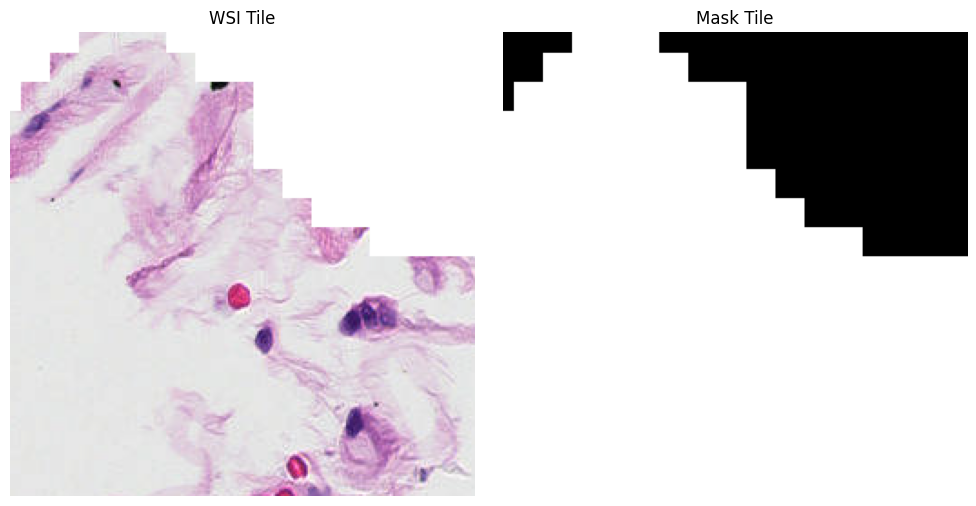

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(wsi_tile)
axes[0].set_title("WSI Tile")
axes[0].axis("off")

axes[1].imshow(binary_mask, cmap="gray")
axes[1].set_title("Mask Tile")
axes[1].axis("off")

plt.tight_layout()
plt.show()

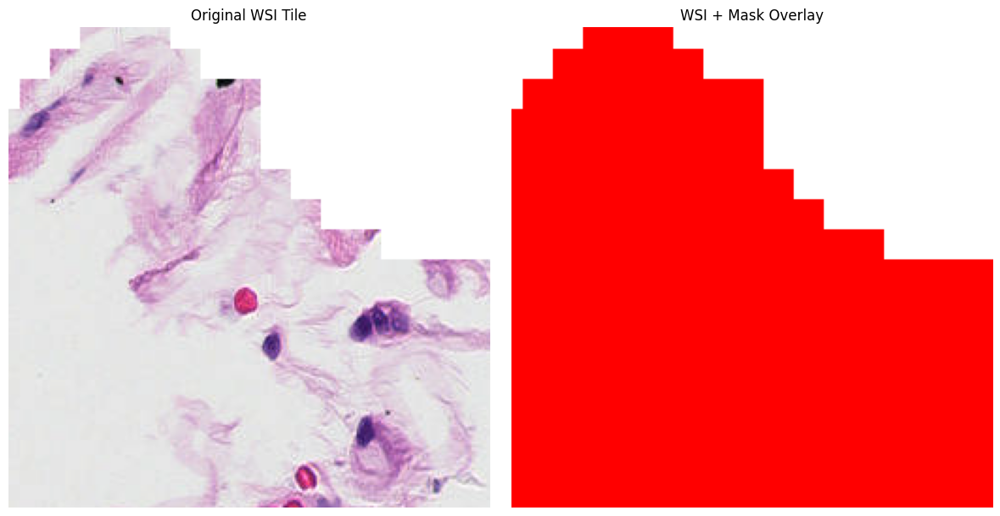

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Convert WSI tile to NumPy
wsi_array = np.array(wsi_tile)

# Create mask overlay
overlay = wsi_array.copy()

# Pixels where annotation exists
mask_pixels = binary_mask > 0

# Mark annotated pixels
overlay[mask_pixels] = [255, 0, 0]

# Display
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(wsi_array)
axes[0].set_title("Original WSI Tile")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("WSI + Mask Overlay")
axes[1].axis("off")

plt.tight_layout()
plt.show()


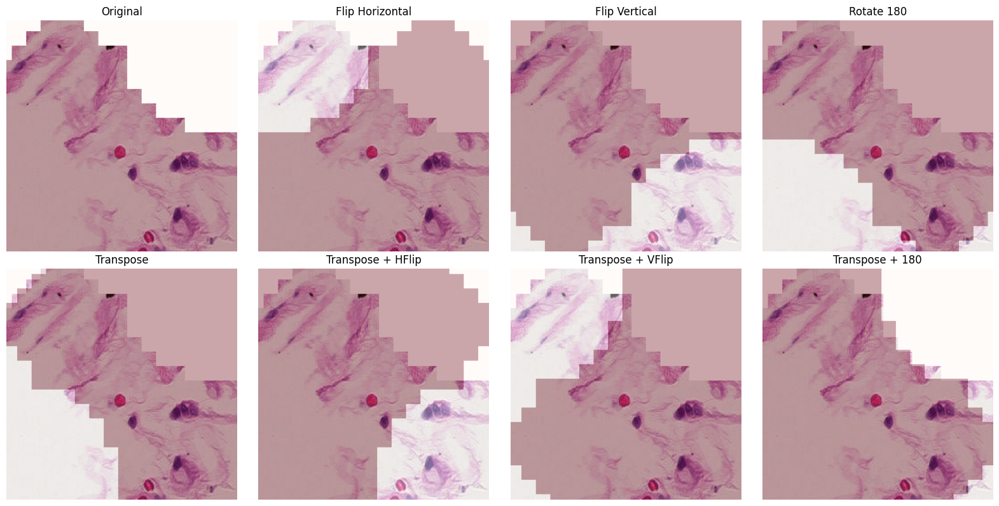

In [59]:
import numpy as np
import matplotlib.pyplot as plt

wsi_array = np.array(wsi_tile)

# Original mask
m = binary_mask

# Test common orientation possibilities
masks = {
    "Original": m,
    "Flip Horizontal": np.fliplr(m),
    "Flip Vertical": np.flipud(m),
    "Rotate 180": np.rot90(m, 2),
    "Transpose": m.T,
    "Transpose + HFlip": np.fliplr(m.T),
    "Transpose + VFlip": np.flipud(m.T),
    "Transpose + 180": np.rot90(m.T, 2),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, (name, test_mask) in zip(axes.ravel(), masks.items()):
    ax.imshow(wsi_array)
    ax.imshow(
        test_mask,
        cmap="Reds",
        alpha=0.35,
        vmin=0,
        vmax=1
    )
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

===== MASK VS TISSUE =====
Tissue pixels: 9353
Annotation pixels: 50208
Intersection: 9353
Union: 50208
IoU: 0.1863
Annotation inside tissue: 18.63 %


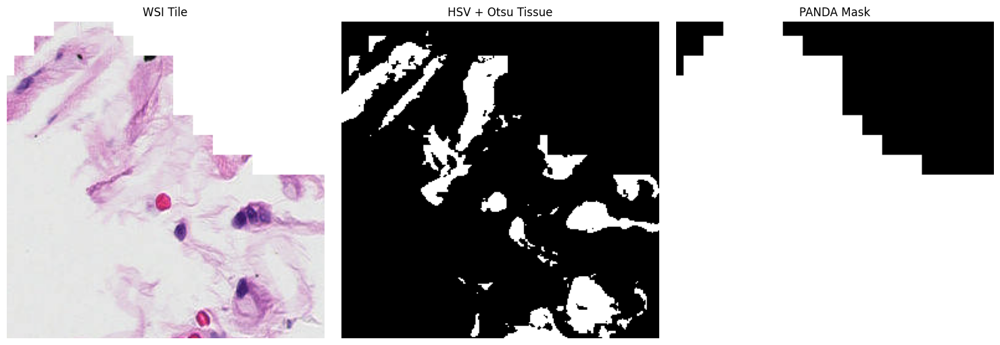

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# WSI tile as NumPy
wsi_array = np.array(wsi_tile)


# 1. Tissue detection

hsv = cv2.cvtColor(wsi_array, cv2.COLOR_RGB2HSV)

# Saturation channel
saturation = hsv[:, :, 1]

# Otsu threshold
_, tissue_mask = cv2.threshold(
    saturation,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

tissue_mask = tissue_mask > 0


# 2. Annotation mask

annotation_mask = binary_mask > 0


# 3. Calculate overlap

intersection = np.logical_and(
    tissue_mask,
    annotation_mask
).sum()

union = np.logical_or(
    tissue_mask,
    annotation_mask
).sum()

iou = intersection / union if union > 0 else 0

print("===== MASK VS TISSUE =====")
print("Tissue pixels:", tissue_mask.sum())
print("Annotation pixels:", annotation_mask.sum())
print("Intersection:", intersection)
print("Union:", union)
print("IoU:", round(iou, 4))

print(
    "Annotation inside tissue:",
    round(
        100 * intersection / annotation_mask.sum(),
        2
    ),
    "%"
)


# 4. Visualize

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(wsi_array)
axes[0].set_title("WSI Tile")
axes[0].axis("off")

axes[1].imshow(tissue_mask, cmap="gray")
axes[1].set_title("HSV + Otsu Tissue")
axes[1].axis("off")

axes[2].imshow(annotation_mask, cmap="gray")
axes[2].set_title("PANDA Mask")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [61]:
import rasterio
import numpy as np

with rasterio.open(mask_path) as src:

    # Read a reduced overview of the complete mask.
    # This avoids loading the full-resolution mask.
    overview = src.read(
        out_shape=(3, 1024, 1024),
        resampling=rasterio.enums.Resampling.nearest
    )

print("Overview shape:", overview.shape)

# The first channel contains the Karolinska class value
mask_overview = overview[0]

unique_values, counts = np.unique(
    mask_overview,
    return_counts=True
)

print("\nMask classes found:")
for value, count in zip(unique_values, counts):
    percentage = 100 * count / mask_overview.size
    print(
        f"Value {value}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

Overview shape: (3, 1024, 1024)

Mask classes found:
Value 0: 1,012,673 pixels (96.58%)
Value 1: 35,903 pixels (3.42%)


In [62]:
# Find the first Radboud slide
radboud_row = train_df[
    train_df["data_provider"].str.lower() == "radboud"
].iloc[0]

radboud_id = radboud_row["image_id"]

radboud_wsi_path = TRAIN_IMAGES / f"{radboud_id}.tiff"
radboud_mask_path = TRAIN_MASKS / f"{radboud_id}_mask.tiff"

print("Radboud sample:")
print("Image ID:", radboud_id)
print("Data provider:", radboud_row["data_provider"])
print("ISUP grade:", radboud_row["isup_grade"])
print("Gleason score:", radboud_row["gleason_score"])

print("\nWSI exists:", radboud_wsi_path.exists())
print("Mask exists:", radboud_mask_path.exists())

Radboud sample:
Image ID: 0018ae58b01bdadc8e347995b69f99aa
Data provider: radboud
ISUP grade: 4
Gleason score: 4+4

WSI exists: True
Mask exists: True


In [63]:
import rasterio
import numpy as np

with rasterio.open(radboud_mask_path) as src:

    overview = src.read(
        out_shape=(3, 1024, 1024),
        resampling=rasterio.enums.Resampling.nearest
    )

print("Overview shape:", overview.shape)

# First channel
mask_overview = overview[0]

unique_values, counts = np.unique(
    mask_overview,
    return_counts=True
)

print("\nRadboud mask classes found:")

for value, count in zip(unique_values, counts):
    percentage = 100 * count / mask_overview.size

    print(
        f"Value {value}: "
        f"{count:,} pixels "
        f"({percentage:.2f}%)"
    )

Overview shape: (3, 1024, 1024)

Radboud mask classes found:
Value 0: 827,333 pixels (78.90%)
Value 1: 171,541 pixels (16.36%)
Value 2: 1,411 pixels (0.13%)
Value 4: 48,291 pixels (4.61%)


In [64]:
import rasterio
import numpy as np

with rasterio.open(radboud_mask_path) as src:
    overview = src.read(
        out_shape=(3, 1024, 1024),
        resampling=rasterio.enums.Resampling.nearest
    )

print("Channel shapes:", overview.shape)

for i in range(3):
    values = np.unique(overview[i])

    print(f"\nChannel {i + 1}:")
    print("Unique values:", values[:20])
    print("Number of unique values:", len(values))

Channel shapes: (3, 1024, 1024)

Channel 1:
Unique values: [0 1 2 4]
Number of unique values: 4

Channel 2:
Unique values: [0]
Number of unique values: 1

Channel 3:
Unique values: [0]
Number of unique values: 1


In [65]:

#  - Final Configuration

N_SLIDES = 200

TILE_SIZE = 256

# Minimum fraction of the tile that must contain tissue
#  calculate this using HSV + Otsu.
MIN_TISSUE_FRACTION = 0.50

# Output directories
OUTPUT_DIR = Path("/kaggle/working/pathoscope_tiles")

IMG_DIR = OUTPUT_DIR / "images"
MASK_DIR = OUTPUT_DIR / "masks"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

print("N_SLIDES:", N_SLIDES)
print("TILE_SIZE:", TILE_SIZE)
print("MIN_TISSUE_FRACTION:", MIN_TISSUE_FRACTION)



N_SLIDES: 200
TILE_SIZE: 256
MIN_TISSUE_FRACTION: 0.5


In [66]:
import cv2
import numpy as np

def get_tissue_mask(tile_rgb):
    """
    Detect tissue using HSV saturation + Otsu thresholding.

    Parameters
    ----------
    tile_rgb : numpy.ndarray
        RGB image tile of shape (H, W, 3)

    Returns
    -------
    tissue_mask : numpy.ndarray
        Boolean mask of shape (H, W)
    """

    # RGB -> HSV
    hsv = cv2.cvtColor(tile_rgb, cv2.COLOR_RGB2HSV)

    # Saturation channel
    saturation = hsv[:, :, 1]

    # Otsu threshold
    _, mask = cv2.threshold(
        saturation,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return mask > 0


print("Tissue detection function created.")

Tissue detection function created.


In [67]:
# Convert our previously loaded WSI tile to NumPy
test_tile = np.array(wsi_tile)

# Tissue mask
test_tissue_mask = get_tissue_mask(test_tile)

# Calculate tissue fraction
tissue_fraction = test_tissue_mask.mean()

print("Tile shape:", test_tile.shape)
print("Tissue pixels:", test_tissue_mask.sum())
print("Total pixels:", test_tissue_mask.size)
print("Tissue fraction:", round(tissue_fraction, 4))
print(
    "Tissue percentage:",
    round(tissue_fraction * 100, 2),
    "%"
)

# Check whether this tile passes our current threshold
print(
    "Passes tissue threshold:",
    tissue_fraction >= MIN_TISSUE_FRACTION
)

Tile shape: (256, 256, 3)
Tissue pixels: 9353
Total pixels: 65536
Tissue fraction: 0.1427
Tissue percentage: 14.27 %
Passes tissue threshold: False


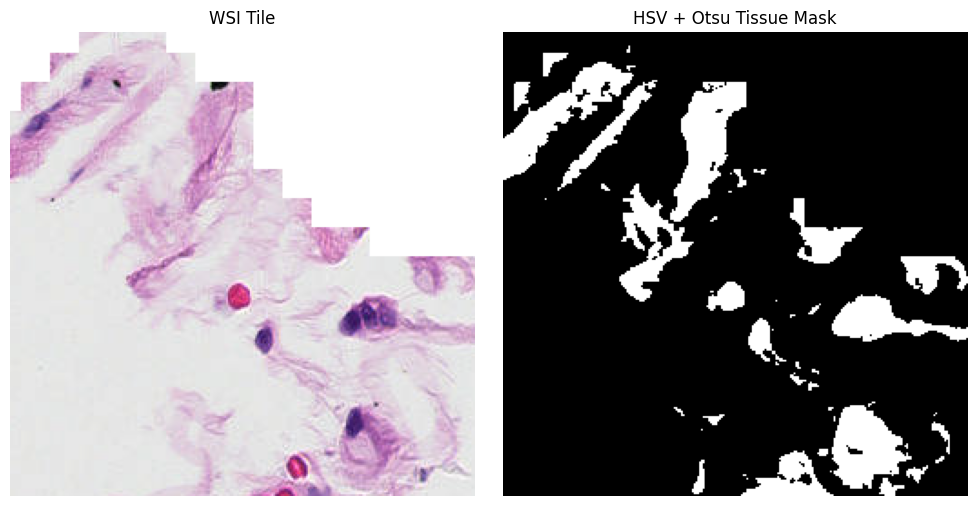

In [68]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(test_tile)
axes[0].set_title("WSI Tile")
axes[0].axis("off")

axes[1].imshow(test_tissue_mask, cmap="gray")
axes[1].set_title("HSV + Otsu Tissue Mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Open the sample WSI
sample_slide = openslide.OpenSlide(str(wsi_path))

slide_width, slide_height = sample_slide.dimensions

# Sample a 10 × 10 grid across the WSI
grid_size = 10
fractions = []
coordinates = []

for gy in range(grid_size):
    for gx in range(grid_size):

        x = int(gx * slide_width / grid_size)
        y = int(gy * slide_height / grid_size)

        # Make sure the 256x256 tile stays inside the WSI
        if x + TILE_SIZE > slide_width:
            x = slide_width - TILE_SIZE

        if y + TILE_SIZE > slide_height:
            y = slide_height - TILE_SIZE

        tile = np.array(
            sample_slide.read_region(
                (x, y),
                0,
                (TILE_SIZE, TILE_SIZE)
            ).convert("RGB")
        )

        tissue_mask = get_tissue_mask(tile)
        fraction = tissue_mask.mean()

        fractions.append(fraction)
        coordinates.append((x, y))

fractions = np.array(fractions)

print("Number of sampled tiles:", len(fractions))
print("Minimum tissue fraction:", round(fractions.min(), 4))
print("Maximum tissue fraction:", round(fractions.max(), 4))
print("Mean tissue fraction:", round(fractions.mean(), 4))
print("Median tissue fraction:", round(np.median(fractions), 4))

print("\nPercentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"{p}th percentile:", round(np.percentile(fractions, p), 4))

Number of sampled tiles: 100
Minimum tissue fraction: 0.0
Maximum tissue fraction: 0.7165
Mean tissue fraction: 0.0227
Median tissue fraction: 0.0

Percentiles:
10th percentile: 0.0
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 0.0
90th percentile: 0.0


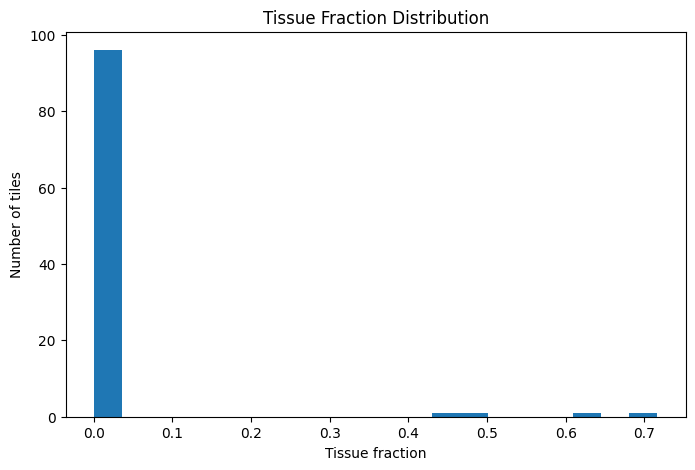

In [70]:
plt.figure(figsize=(8, 5))

plt.hist(fractions, bins=20)

plt.xlabel("Tissue fraction")
plt.ylabel("Number of tiles")
plt.title("Tissue Fraction Distribution")

plt.show()

In [71]:
import numpy as np

def calculate_tissue_fraction(tile_rgb):
    """
    Calculate tissue fraction using HSV saturation + Otsu.
    """
    tissue_mask = get_tissue_mask(tile_rgb)
    return float(tissue_mask.mean())


def generate_tile_coordinates(slide):
    """
    Generate every non-overlapping 256x256 tile coordinate
    across the level-0 WSI.
    """

    width, height = slide.dimensions

    coordinates = []

    for y in range(0, height - TILE_SIZE + 1, TILE_SIZE):
        for x in range(0, width - TILE_SIZE + 1, TILE_SIZE):
            coordinates.append((x, y))

    return coordinates


print("Tile-ranking functions created.")

Tile-ranking functions created.


In [72]:
sample_slide = openslide.OpenSlide(str(wsi_path))

coordinates = generate_tile_coordinates(sample_slide)

print("WSI dimensions:", sample_slide.dimensions)
print("Total 256×256 tiles:", len(coordinates))
print("First 5 coordinates:", coordinates[:5])
print("Last 5 coordinates:", coordinates[-5:])

WSI dimensions: (27648, 29440)
Total 256×256 tiles: 12420
First 5 coordinates: [(0, 0), (256, 0), (512, 0), (768, 0), (1024, 0)]
Last 5 coordinates: [(26368, 29184), (26624, 29184), (26880, 29184), (27136, 29184), (27392, 29184)]


In [73]:
import numpy as np
import cv2
import openslide

def rank_tiles_by_tissue(slide, tile_size=256):
    """
    Rank 256x256 WSI tiles by tissue fraction.

    Tissue detection:
        RGB -> HSV -> Saturation -> Otsu threshold

    Ranking is performed on a low-resolution WSI level
    to avoid reading thousands of full-resolution tiles.
    """

    width, height = slide.dimensions

    # Use the lowest-resolution available level
    low_level = slide.level_count - 1
    low_width, low_height = slide.level_dimensions[low_level]

    print("Using low-resolution level:", low_level)
    print("Low-resolution dimensions:", (low_width, low_height))

    # Read entire low-resolution WSI
    lowres = slide.read_region(
        (0, 0),
        low_level,
        (low_width, low_height)
    ).convert("RGB")

    lowres = np.asarray(lowres)

    # RGB -> HSV
    hsv = cv2.cvtColor(lowres, cv2.COLOR_RGB2HSV)

    # Saturation channel
    saturation = hsv[:, :, 1]

    # Otsu threshold
    _, tissue_mask = cv2.threshold(
        saturation,
        0,
        1,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Downsampling factor from level 0 -> low level
    downsample = slide.level_downsamples[low_level]

    tile_scores = []

    for y in range(0, height - tile_size + 1, tile_size):

        for x in range(0, width - tile_size + 1, tile_size):

            # Convert level-0 coordinates to low-resolution coordinates
            x1 = int(x / downsample)
            y1 = int(y / downsample)

            x2 = int((x + tile_size) / downsample)
            y2 = int((y + tile_size) / downsample)

            region = tissue_mask[y1:y2, x1:x2]

            if region.size == 0:
                tissue_fraction = 0.0
            else:
                tissue_fraction = float(region.mean())

            tile_scores.append({
                "x": x,
                "y": y,
                "tissue_fraction": tissue_fraction
            })

    # Highest tissue first
    tile_scores.sort(
        key=lambda item: item["tissue_fraction"],
        reverse=True
    )

    return tile_scores

In [74]:
sample_slide = openslide.OpenSlide(str(wsi_path))

ranked_tiles = rank_tiles_by_tissue(
    sample_slide,
    tile_size=TILE_SIZE
)

print("Total ranked tiles:", len(ranked_tiles))

print("\nTop 10 tissue-rich tiles:")
for tile in ranked_tiles[:10]:
    print(tile)

Using low-resolution level: 2
Low-resolution dimensions: (1728, 1840)
Total ranked tiles: 12420

Top 10 tissue-rich tiles:
{'x': 6144, 'y': 8192, 'tissue_fraction': 1.0}
{'x': 6400, 'y': 8448, 'tissue_fraction': 1.0}
{'x': 6656, 'y': 8704, 'tissue_fraction': 1.0}
{'x': 6912, 'y': 9216, 'tissue_fraction': 1.0}
{'x': 7168, 'y': 9472, 'tissue_fraction': 1.0}
{'x': 7680, 'y': 9984, 'tissue_fraction': 1.0}
{'x': 7424, 'y': 12800, 'tissue_fraction': 1.0}
{'x': 7424, 'y': 13568, 'tissue_fraction': 1.0}
{'x': 7168, 'y': 13824, 'tissue_fraction': 1.0}
{'x': 6144, 'y': 19456, 'tissue_fraction': 1.0}


Number of tiles: 12420
Minimum: 0.0
Maximum: 1.0
Mean: 0.023281816123188404
Median: 0.0

Percentiles:
1%: 0.0000
5%: 0.0000
10%: 0.0000
25%: 0.0000
50%: 0.0000
75%: 0.0000
90%: 0.0000
95%: 0.0000
99%: 0.8899


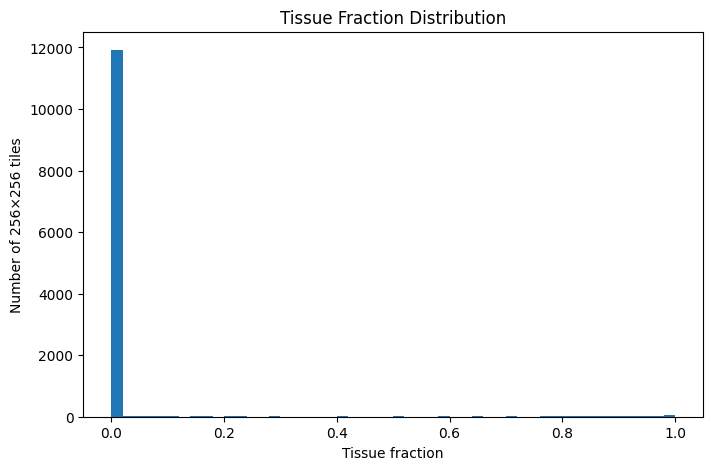

In [75]:
import numpy as np
import matplotlib.pyplot as plt

tissue_scores = np.array([
    tile["tissue_fraction"]
    for tile in ranked_tiles
])

print("Number of tiles:", len(tissue_scores))
print("Minimum:", tissue_scores.min())
print("Maximum:", tissue_scores.max())
print("Mean:", tissue_scores.mean())
print("Median:", np.median(tissue_scores))

print("\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"{p}%: {np.percentile(tissue_scores, p):.4f}")

plt.figure(figsize=(8, 5))
plt.hist(tissue_scores, bins=50)
plt.xlabel("Tissue fraction")
plt.ylabel("Number of 256×256 tiles")
plt.title("Tissue Fraction Distribution")
plt.show()

In [76]:
TOP_K_TILES = 64

selected_tiles = ranked_tiles[:TOP_K_TILES]

print("Selected tiles:", len(selected_tiles))

print("\nTissue fraction range:")
print("Highest:", selected_tiles[0]["tissue_fraction"])
print("Lowest:", selected_tiles[-1]["tissue_fraction"])

print("\nSelected tile coordinates:")
for i, tile in enumerate(selected_tiles[:10], start=1):
    print(
        f"{i:02d}. "
        f"x={tile['x']}, "
        f"y={tile['y']}, "
        f"tissue={tile['tissue_fraction']:.4f}"
    )

Selected tiles: 64

Tissue fraction range:
Highest: 1.0
Lowest: 0.96875

Selected tile coordinates:
01. x=6144, y=8192, tissue=1.0000
02. x=6400, y=8448, tissue=1.0000
03. x=6656, y=8704, tissue=1.0000
04. x=6912, y=9216, tissue=1.0000
05. x=7168, y=9472, tissue=1.0000
06. x=7680, y=9984, tissue=1.0000
07. x=7424, y=12800, tissue=1.0000
08. x=7424, y=13568, tissue=1.0000
09. x=7168, y=13824, tissue=1.0000
10. x=6144, y=19456, tissue=1.0000


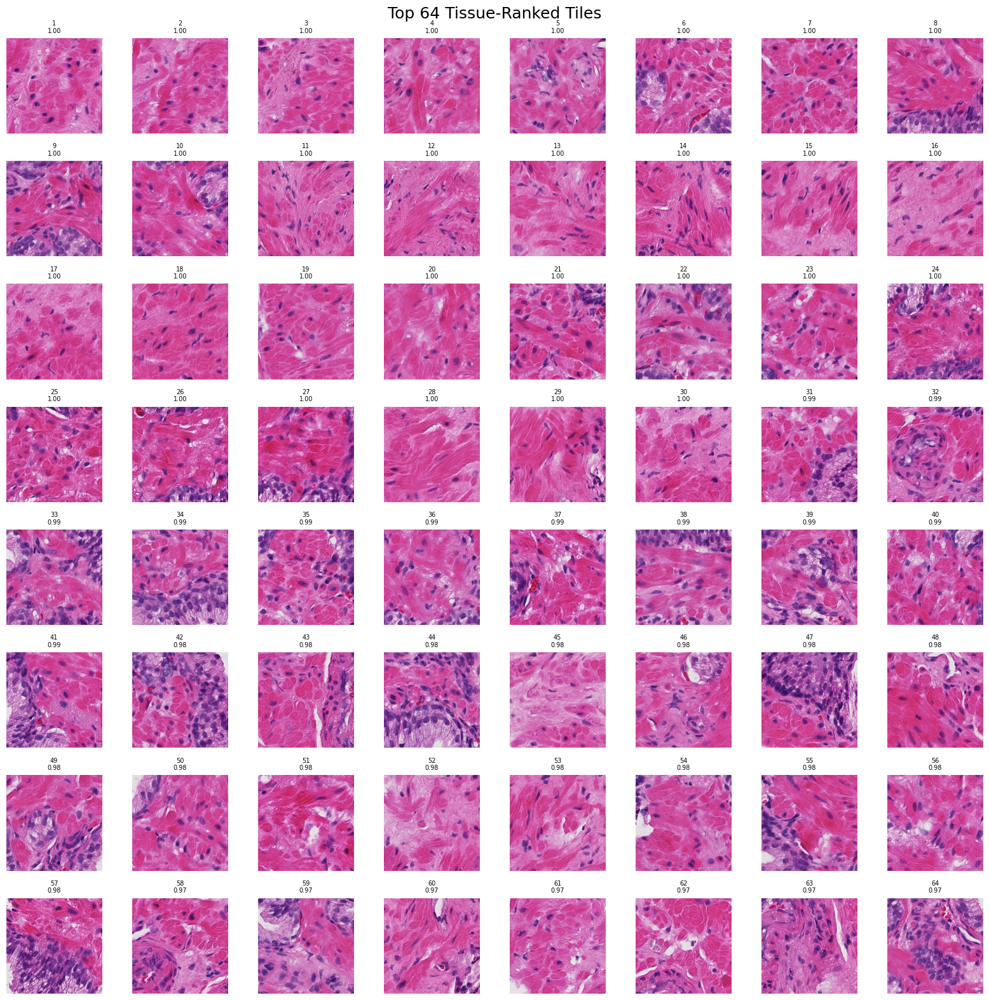

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import openslide

# Open the sample WSI
sample_slide = openslide.OpenSlide(str(wsi_path))

# 8 × 8 = 64 tiles
fig, axes = plt.subplots(8, 8, figsize=(16, 16))

for i, tile in enumerate(selected_tiles):

    x = tile["x"]
    y = tile["y"]

    # Read the actual 256×256 tile at full resolution
    region = sample_slide.read_region(
        (x, y),
        0,
        (TILE_SIZE, TILE_SIZE)
    ).convert("RGB")

    tile_rgb = np.asarray(region)

    ax = axes.flat[i]
    ax.imshow(tile_rgb)
    ax.set_title(
        f"{i+1}\n{tile['tissue_fraction']:.2f}",
        fontsize=7
    )
    ax.axis("off")

plt.suptitle(
    "Top 64 Tissue-Ranked Tiles",
    fontsize=18
)

plt.tight_layout()
plt.show()

In [78]:
import rasterio
import numpy as np
from pathlib import Path

# Sample information


sample_id = wsi_path.stem

TRAIN_CSV = Path(
    "/kaggle/input/competitions/"
    "prostate-cancer-grade-assessment/train.csv"
)

train_df = pd.read_csv(TRAIN_CSV)

sample_row = train_df[
    train_df["image_id"] == sample_id
].iloc[0]

provider = sample_row["data_provider"]
isup_grade = int(sample_row["isup_grade"])
gleason_score = sample_row["gleason_score"]

print("Sample ID:", sample_id)
print("Provider:", provider)
print("ISUP grade:", isup_grade)
print("Gleason score:", gleason_score)



# Find mask


mask_path = Path(
    "/kaggle/input/competitions/"
    "prostate-cancer-grade-assessment/"
    "train_label_masks"
) / f"{sample_id}_mask.tiff"

print("\nMask path:", mask_path)
print("Mask exists:", mask_path.exists())



# Read selected tile masks


tile_mask_results = []

with rasterio.open(mask_path) as mask_src:

    print("\nMask dimensions:",
          mask_src.width,
          mask_src.height)

    print("Mask bands:", mask_src.count)
    print("Mask dtype:", mask_src.dtypes)

    for tile_number, tile in enumerate(selected_tiles, start=1):

        x = tile["x"]
        y = tile["y"]

        # Rasterio uses:
        # Window(col_off, row_off, width, height)
        window = rasterio.windows.Window(
            x,
            y,
            TILE_SIZE,
            TILE_SIZE
        )

        # Read first channel.
        # PANDA annotation is stored in this channel.
        mask = mask_src.read(
            1,
            window=window
        )

        unique_values, counts = np.unique(
            mask,
            return_counts=True
        )

        value_counts = dict(
            zip(
                unique_values.tolist(),
                counts.tolist()
            )
        )

        tile_mask_results.append({
            "tile_number": tile_number,
            "x": x,
            "y": y,
            "tissue_fraction": tile["tissue_fraction"],
            "mask_values": value_counts
        })


print("\nFirst 10 tile mask summaries:")

for result in tile_mask_results[:10]:
    print(
        f"Tile {result['tile_number']:02d} | "
        f"x={result['x']:5d} | "
        f"y={result['y']:5d} | "
        f"tissue={result['tissue_fraction']:.4f} | "
        f"mask={result['mask_values']}"
    )

Sample ID: 0005f7aaab2800f6170c399693a96917
Provider: karolinska
ISUP grade: 0
Gleason score: 0+0

Mask path: /kaggle/input/competitions/prostate-cancer-grade-assessment/train_label_masks/0005f7aaab2800f6170c399693a96917_mask.tiff
Mask exists: True

Mask dimensions: 27648 29440
Mask bands: 3
Mask dtype: ('uint8', 'uint8', 'uint8')

First 10 tile mask summaries:
Tile 01 | x= 6144 | y= 8192 | tissue=1.0000 | mask={1: 65536}
Tile 02 | x= 6400 | y= 8448 | tissue=1.0000 | mask={1: 65536}
Tile 03 | x= 6656 | y= 8704 | tissue=1.0000 | mask={1: 65536}
Tile 04 | x= 6912 | y= 9216 | tissue=1.0000 | mask={1: 65536}
Tile 05 | x= 7168 | y= 9472 | tissue=1.0000 | mask={1: 65536}
Tile 06 | x= 7680 | y= 9984 | tissue=1.0000 | mask={1: 65536}
Tile 07 | x= 7424 | y=12800 | tissue=1.0000 | mask={1: 65536}
Tile 08 | x= 7424 | y=13568 | tissue=1.0000 | mask={1: 65536}
Tile 09 | x= 7168 | y=13824 | tissue=1.0000 | mask={1: 65536}
Tile 10 | x= 6144 | y=19456 | tissue=1.0000 | mask={1: 65536}


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [79]:

# Final label distribution for selected 64 tiles

print("========================================")
print("SELECTED TILE LABEL DISTRIBUTION")
print("========================================")

label_counts = {
    -1: 0,   # unknown
     0: 0,   # benign / non-tumor
     1: 0    # tumor
}

mask_value_counts = {}

for result in tile_mask_results:

    # Recover the original mask values
    for value, count in result["mask_values"].items():
        mask_value_counts[value] = (
            mask_value_counts.get(value, 0) + count
        )

    # Calculate tile label
    mask_values = set(result["mask_values"].keys())

    if provider == "karolinska":

        if 2 in mask_values:
            label = 1
        elif 1 in mask_values:
            label = 0
        else:
            label = -1

    elif provider == "radboud":

        if any(v in mask_values for v in [3, 4, 5]):
            label = 1
        elif any(v in mask_values for v in [1, 2]):
            label = 0
        else:
            label = -1

    result["tile_label"] = label
    label_counts[label] += 1


print("Original mask pixel values:")
for value in sorted(mask_value_counts):
    print(
        f"Value {value}: "
        f"{mask_value_counts[value]:,} pixels"
    )

print("\nTile labels:")
print("Unknown       (-1):", label_counts[-1])
print("Benign        ( 0):", label_counts[0])
print("Tumor         ( 1):", label_counts[1])

SELECTED TILE LABEL DISTRIBUTION
Original mask pixel values:
Value 1: 4,194,304 pixels

Tile labels:
Unknown       (-1): 0
Benign        ( 0): 64
Tumor         ( 1): 0


In [80]:

# Validate a Radboud cancer slide


RADBOUD_ID = "0018ae58b01bdadc8e347995b69f99aa"

radboud_wsi_path = (
    Path("/kaggle/input/competitions/"
         "prostate-cancer-grade-assessment/train_images")
    / f"{RADBOUD_ID}.tiff"
)

radboud_mask_path = (
    Path("/kaggle/input/competitions/"
         "prostate-cancer-grade-assessment/train_label_masks")
    / f"{RADBOUD_ID}_mask.tiff"
)

print("WSI exists:", radboud_wsi_path.exists())
print("Mask exists:", radboud_mask_path.exists())

radboud_row = train_df[
    train_df["image_id"] == RADBOUD_ID
].iloc[0]

print("\nProvider:", radboud_row["data_provider"])
print("ISUP:", radboud_row["isup_grade"])
print("Gleason:", radboud_row["gleason_score"])

WSI exists: True
Mask exists: True

Provider: radboud
ISUP: 4
Gleason: 4+4


In [81]:
radboud_slide = openslide.OpenSlide(
    str(radboud_wsi_path)
)

radboud_ranked_tiles = rank_tiles_by_tissue(
    radboud_slide,
    tile_size=TILE_SIZE
)

radboud_selected_tiles = radboud_ranked_tiles[:TOP_K_TILES]

print("\nWSI dimensions:", radboud_slide.dimensions)
print("Total tiles:", len(radboud_ranked_tiles))
print("Selected tiles:", len(radboud_selected_tiles))
print(
    "Selected tissue range:",
    radboud_selected_tiles[0]["tissue_fraction"],
    "to",
    radboud_selected_tiles[-1]["tissue_fraction"]
)

Using low-resolution level: 2
Low-resolution dimensions: (368, 1584)

WSI dimensions: (5888, 25344)
Total tiles: 2277
Selected tiles: 64
Selected tissue range: 1.0 to 0.9921875


In [82]:
radboud_mask_results = []

with rasterio.open(radboud_mask_path) as mask_src:

    for tile_number, tile in enumerate(
        radboud_selected_tiles,
        start=1
    ):

        x = tile["x"]
        y = tile["y"]

        window = rasterio.windows.Window(
            x,
            y,
            TILE_SIZE,
            TILE_SIZE
        )

        mask = mask_src.read(
            1,
            window=window
        )

        unique_values, counts = np.unique(
            mask,
            return_counts=True
        )

        value_counts = dict(
            zip(
                unique_values.tolist(),
                counts.tolist()
            )
        )

        radboud_mask_results.append({
            "tile_number": tile_number,
            "x": x,
            "y": y,
            "tissue_fraction": tile["tissue_fraction"],
            "mask_values": value_counts
        })

print("\nFirst 10 Radboud mask summaries:")

for result in radboud_mask_results[:10]:
    print(
        f"Tile {result['tile_number']:02d} | "
        f"x={result['x']:5d} | "
        f"y={result['y']:5d} | "
        f"tissue={result['tissue_fraction']:.4f} | "
        f"mask={result['mask_values']}"
    )


First 10 Radboud mask summaries:
Tile 01 | x= 1792 | y= 1024 | tissue=1.0000 | mask={1: 65268, 2: 268}
Tile 02 | x= 1792 | y= 1280 | tissue=1.0000 | mask={1: 65536}
Tile 03 | x= 1792 | y= 2048 | tissue=1.0000 | mask={1: 65536}
Tile 04 | x= 2048 | y= 2048 | tissue=1.0000 | mask={1: 64620, 2: 916}
Tile 05 | x= 1792 | y= 2304 | tissue=1.0000 | mask={1: 65080, 2: 456}
Tile 06 | x= 2304 | y= 2560 | tissue=1.0000 | mask={1: 65536}
Tile 07 | x= 2560 | y= 2560 | tissue=1.0000 | mask={1: 65536}
Tile 08 | x= 2048 | y= 4096 | tissue=1.0000 | mask={1: 32260, 4: 33276}
Tile 09 | x= 1280 | y= 4864 | tissue=1.0000 | mask={1: 34500, 4: 31036}
Tile 10 | x= 1536 | y= 4864 | tissue=1.0000 | mask={1: 27104, 4: 38432}


In [83]:

# Radboud selected-tile label distribution


radboud_label_counts = {
    -1: 0,   # unknown
     0: 0,   # non-tumor
     1: 0    # tumor
}

radboud_mask_pixel_counts = {}

for result in radboud_mask_results:

    mask_values = set(result["mask_values"].keys())

    # Count original mask pixels
    for value, count in result["mask_values"].items():
        radboud_mask_pixel_counts[value] = (
            radboud_mask_pixel_counts.get(value, 0) + count
        )

    # Provider-specific classification
    if any(v in mask_values for v in [3, 4, 5]):
        label = 1

    elif any(v in mask_values for v in [1, 2]):
        label = 0

    else:
        label = -1

    result["tile_label"] = label
    radboud_label_counts[label] += 1


print("========================================")
print("RADBOUD SELECTED TILE DISTRIBUTION")
print("========================================")

print("\nOriginal mask pixel values:")

for value in sorted(radboud_mask_pixel_counts):
    print(
        f"Value {value}: "
        f"{radboud_mask_pixel_counts[value]:,} pixels"
    )

print("\nTile labels:")
print("Unknown       (-1):", radboud_label_counts[-1])
print("Non-tumor     ( 0):", radboud_label_counts[0])
print("Tumor         ( 1):", radboud_label_counts[1])

RADBOUD SELECTED TILE DISTRIBUTION

Original mask pixel values:
Value 0: 7,912 pixels
Value 1: 2,852,372 pixels
Value 2: 24,344 pixels
Value 4: 1,309,676 pixels

Tile labels:
Unknown       (-1): 0
Non-tumor     ( 0): 19
Tumor         ( 1): 45


In [84]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import openslide
import rasterio
import os
import shutil
import zipfile
from tqdm.auto import tqdm


# PathoScope Notebook 01 configuration


N_SLIDES = 200

TILE_SIZE = 256
TOP_K_TILES = 64

BASE_DIR = Path(
    "/kaggle/input/competitions/"
    "prostate-cancer-grade-assessment"
)

TRAIN_IMAGES = BASE_DIR / "train_images"
TRAIN_MASKS = BASE_DIR / "train_label_masks"
TRAIN_CSV = BASE_DIR / "train.csv"

OUTPUT_DIR = Path("/kaggle/working/pathoscope_tiles")

IMG_DIR = OUTPUT_DIR / "images"
MASK_DIR = OUTPUT_DIR / "masks"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IMG_DIR.mkdir(parents=True, exist_ok=True)
MASK_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration ready.")
print("N_SLIDES:", N_SLIDES)
print("TILE_SIZE:", TILE_SIZE)
print("TOP_K_TILES:", TOP_K_TILES)
print("Output:", OUTPUT_DIR)

Configuration ready.
N_SLIDES: 200
TILE_SIZE: 256
TOP_K_TILES: 64
Output: /kaggle/working/pathoscope_tiles


In [85]:
train_df = pd.read_csv(TRAIN_CSV)

print("Total records:", len(train_df))
print("Columns:")
print(train_df.columns.tolist())

display(train_df.head())

Total records: 10616
Columns:
['image_id', 'data_provider', 'isup_grade', 'gleason_score']


,image_id,data_provider,isup_grade,gleason_score
0,0005f7aaab2800f6170c399693a96917,karolinska,0,0+0
1,000920ad0b612851f8e01bcc880d9b3d,karolinska,0,0+0
2,0018ae58b01bdadc8e347995b69f99aa,radboud,4,4+4
3,001c62abd11fa4b57bf7a6c603a11bb9,karolinska,4,4+4
4,001d865e65ef5d2579c190a0e0350d8f,karolinska,0,0+0


In [86]:
print("\nProvider distribution:")
print(train_df["data_provider"].value_counts())

print("\nISUP distribution:")
print(
    train_df["isup_grade"]
    .value_counts()
    .sort_index()
)


Provider distribution:
data_provider
karolinska    5456
radboud       5160
Name: count, dtype: int64

ISUP distribution:
isup_grade
0    2892
1    2666
2    1343
3    1242
4    1249
5    1224
Name: count, dtype: int64


In [87]:
from sklearn.model_selection import train_test_split

# Make sure all grades are represented as well as possible
test_df, _ = train_test_split(
    train_df,
    train_size=N_SLIDES,
    stratify=train_df["isup_grade"],
    random_state=42
)

test_df = test_df.reset_index(drop=True)

print("Slides selected:", len(test_df))

print("\nISUP distribution:")
print(
    test_df["isup_grade"]
    .value_counts()
    .sort_index()
)

print("\nProvider distribution:")
print(
    test_df["data_provider"]
    .value_counts()
)

Slides selected: 200

ISUP distribution:
isup_grade
0    55
1    50
2    25
3    23
4    24
5    23
Name: count, dtype: int64

Provider distribution:
data_provider
radboud       100
karolinska    100
Name: count, dtype: int64


In [88]:
def get_tissue_ranking(slide, tile_size=256):
    """
    Calculate HSV + Otsu tissue score for every
    complete 256x256 tile and rank descending.
    """

    width, height = slide.dimensions

    low_level = slide.level_count - 1
    low_width, low_height = slide.level_dimensions[low_level]

    # Read low-resolution WSI
    lowres = slide.read_region(
        (0, 0),
        low_level,
        (low_width, low_height)
    ).convert("RGB")

    lowres = np.asarray(lowres)

    # HSV saturation
    hsv = cv2.cvtColor(
        lowres,
        cv2.COLOR_RGB2HSV
    )

    saturation = hsv[:, :, 1]

    # Otsu tissue threshold
    _, tissue_mask = cv2.threshold(
        saturation,
        0,
        1,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    downsample = slide.level_downsamples[low_level]

    ranked = []

    for y in range(
        0,
        height - tile_size + 1,
        tile_size
    ):
        for x in range(
            0,
            width - tile_size + 1,
            tile_size
        ):

            x1 = int(x / downsample)
            y1 = int(y / downsample)

            x2 = int(
                (x + tile_size) / downsample
            )
            y2 = int(
                (y + tile_size) / downsample
            )

            region = tissue_mask[
                y1:y2,
                x1:x2
            ]

            tissue_fraction = (
                float(region.mean())
                if region.size > 0
                else 0.0
            )

            ranked.append({
                "x": x,
                "y": y,
                "tissue_fraction": tissue_fraction
            })

    ranked.sort(
        key=lambda z: z["tissue_fraction"],
        reverse=True
    )

    return ranked

In [89]:
def classify_mask_tile(mask, provider):
    """
    Convert PANDA mask values into:

        1  = tumor
        0  = annotated non-tumor
       -1  = unknown/background only
    """

    values = set(
        np.unique(mask).tolist()
    )

    if provider == "karolinska":

        if 2 in values:
            return 1

        elif 1 in values:
            return 0

        else:
            return -1

    elif provider == "radboud":

        if any(
            value in values
            for value in [3, 4, 5]
        ):
            return 1

        elif any(
            value in values
            for value in [1, 2]
        ):
            return 0

        else:
            return -1

    else:
        raise ValueError(
            f"Unknown provider: {provider}"
        )

In [90]:
def process_one_slide(row):

    sample_id = row["image_id"]
    provider = row["data_provider"]

    isup_grade = int(row["isup_grade"])
    gleason_score = row["gleason_score"]

    wsi_path = (
        TRAIN_IMAGES /
        f"{sample_id}.tiff"
    )

    mask_path = (
        TRAIN_MASKS /
        f"{sample_id}_mask.tiff"
    )

    
    # Check WSI
    

    if not wsi_path.exists():
        return [], "missing_wsi"

    
    # Open WSI
    

    slide = openslide.OpenSlide(
        str(wsi_path)
    )

    
    # Tissue ranking
    

    ranked_tiles = get_tissue_ranking(
        slide,
        tile_size=TILE_SIZE
    )

    # Select top tissue-rich tiles
    selected_tiles = ranked_tiles[
        :TOP_K_TILES
    ]

    
    # Mask availability
    

    mask_available = mask_path.exists()

    records = []

    
    # Open mask if available
    

    mask_src = (
        rasterio.open(mask_path)
        if mask_available
        else None
    )

    try:

        for tile_index, tile in enumerate(
            selected_tiles
        ):

            x = tile["x"]
            y = tile["y"]

            
            # Read RGB tile
            

            region = slide.read_region(
                (x, y),
                0,
                (TILE_SIZE, TILE_SIZE)
            ).convert("RGB")

            tile_rgb = np.asarray(region)

            
            # Read mask
            

            if mask_src is not None:

                window = rasterio.windows.Window(
                    x,
                    y,
                    TILE_SIZE,
                    TILE_SIZE
                )

                mask = mask_src.read(
                    1,
                    window=window
                )

                tile_label = classify_mask_tile(
                    mask,
                    provider
                )

            else:

                # Mask unavailable:
                # do NOT treat as benign.
                mask = np.zeros(
                    (TILE_SIZE, TILE_SIZE),
                    dtype=np.uint8
                )

                tile_label = -1

            
            # File names
            

            tile_id = (
                f"{sample_id}_"
                f"x{x}_y{y}"
            )

            image_file = (
                IMG_DIR /
                f"{tile_id}.jpg"
            )

            mask_file = (
                MASK_DIR /
                f"{tile_id}.png"
            )

            
            # Save RGB image
            

            image_bgr = cv2.cvtColor(
                tile_rgb,
                cv2.COLOR_RGB2BGR
            )

            cv2.imwrite(
                str(image_file),
                image_bgr,
                [
                    cv2.IMWRITE_JPEG_QUALITY,
                    95
                ]
            )

            
            # Save original mask values
            

            cv2.imwrite(
                str(mask_file),
                mask
            )

            
            # Metadata
            

            records.append({
                "tile_id": tile_id,
                "image_id": sample_id,
                "data_provider": provider,
                "x": x,
                "y": y,
                "tile_size": TILE_SIZE,
                "tissue_fraction":
                    tile["tissue_fraction"],
                "tile_label": tile_label,
                "isup_grade": isup_grade,
                "gleason_score":
                    gleason_score,
                "mask_available":
                    int(mask_available),
                "image_path":
                    str(image_file),
                "mask_path":
                    str(mask_file)
            })

    finally:

        if mask_src is not None:
            mask_src.close()

        slide.close()

    return records, "success"

In [91]:
validation_ids = [
    "0005f7aaab2800f6170c399693a96917",
    "0018ae58b01bdadc8e347995b69f99aa"
]

for sample_id in validation_ids:

    row = train_df[
        train_df["image_id"] == sample_id
    ].iloc[0]

    records, status = process_one_slide(row)

    print(
        sample_id,
        "| status:",
        status,
        "| tiles:",
        len(records)
    )

    labels = pd.Series(
        [r["tile_label"] for r in records]
    )

    print(
        labels.value_counts()
        .sort_index()
    )

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


0005f7aaab2800f6170c399693a96917 | status: success | tiles: 64
0    64
Name: count, dtype: int64
0018ae58b01bdadc8e347995b69f99aa | status: success | tiles: 64
0    19
1    45
Name: count, dtype: int64


In [92]:

# RUN NOTEBOOK 01 — 200 SLIDE TEST


all_records = []
processing_summary = []

print("=" * 60)
print("PathoScope Notebook 01")
print("200-slide preprocessing test")
print("=" * 60)

for i, (_, row) in enumerate(
    tqdm(
        test_df.iterrows(),
        total=len(test_df),
        desc="Processing slides"
    ),
    start=1
):

    sample_id = row["image_id"]

    try:

        records, status = process_one_slide(row)

        all_records.extend(records)

        processing_summary.append({
            "image_id": sample_id,
            "provider": row["data_provider"],
            "isup_grade": row["isup_grade"],
            "status": status,
            "tiles_generated": len(records)
        })

    except Exception as e:

        processing_summary.append({
            "image_id": sample_id,
            "provider": row["data_provider"],
            "isup_grade": row["isup_grade"],
            "status": "error",
            "tiles_generated": 0,
            "error": str(e)
        })

        print(
            f"\nERROR: {sample_id}"
            f"\n{type(e).__name__}: {e}"
        )



# Convert to DataFrames


tiles_df = pd.DataFrame(all_records)

summary_df = pd.DataFrame(
    processing_summary
)


print("\n" + "=" * 60)
print("PROCESSING COMPLETE")
print("=" * 60)

print("Slides attempted:",
      len(test_df))

print("Successful slides:",
      (summary_df["status"] == "success").sum())

print("Failed slides:",
      (summary_df["status"] == "error").sum())

print("Total tiles:",
      len(tiles_df))

print("\nExpected maximum tiles:",
      len(test_df) * TOP_K_TILES)

print("\nStatus:")
print(
    summary_df["status"]
    .value_counts()
)

PathoScope Notebook 01
200-slide preprocessing test


Processing slides:   0%|          | 0/200 [00:00<?, ?it/s]


PROCESSING COMPLETE
Slides attempted: 200
Successful slides: 200
Failed slides: 0
Total tiles: 12800

Expected maximum tiles: 12800

Status:
status
success    200
Name: count, dtype: int64


In [93]:

# DATASET QUALITY CHECK


print("=" * 60)
print("PathoScope — Dataset Quality Check")
print("=" * 60)

print("\n1. Dataset shape")
print("Rows:", len(tiles_df))
print("Columns:", len(tiles_df.columns))

print("\nColumns:")
print(tiles_df.columns.tolist())


print("\n2. Provider distribution")
print(
    tiles_df["data_provider"]
    .value_counts()
)


print("\n3. Tile label distribution")
print(
    tiles_df["tile_label"]
    .value_counts()
    .sort_index()
)


print("\n4. Unknown labels")
print(
    "Unknown:",
    (tiles_df["tile_label"] == -1).sum()
)


print("\n5. Tumor tiles")
print(
    "Tumor:",
    (tiles_df["tile_label"] == 1).sum()
)


print("\n6. Non-tumor tiles")
print(
    "Non-tumor:",
    (tiles_df["tile_label"] == 0).sum()
)


print("\n7. Tissue fraction")
print(
    tiles_df["tissue_fraction"].describe()
)


print("\n8. ISUP distribution")
print(
    tiles_df["isup_grade"]
    .value_counts()
    .sort_index()
)


print("\n9. Tiles per slide")
tiles_per_slide = (
    tiles_df
    .groupby("image_id")
    .size()
)

print(tiles_per_slide.describe())

print(
    "\nSlides with != 64 tiles:",
    (tiles_per_slide != TOP_K_TILES).sum()
)


print("\n10. Missing files")

missing_images = sum(
    not Path(p).exists()
    for p in tiles_df["image_path"]
)

missing_masks = sum(
    not Path(p).exists()
    for p in tiles_df["mask_path"]
)

print("Missing images:", missing_images)
print("Missing masks:", missing_masks)

PathoScope — Dataset Quality Check

1. Dataset shape
Rows: 12800
Columns: 13

Columns:
['tile_id', 'image_id', 'data_provider', 'x', 'y', 'tile_size', 'tissue_fraction', 'tile_label', 'isup_grade', 'gleason_score', 'mask_available', 'image_path', 'mask_path']

2. Provider distribution
data_provider
radboud       6400
karolinska    6400
Name: count, dtype: int64

3. Tile label distribution
tile_label
-1     838
 0    8569
 1    3393
Name: count, dtype: int64

4. Unknown labels
Unknown: 838

5. Tumor tiles
Tumor: 3393

6. Non-tumor tiles
Non-tumor: 8569

7. Tissue fraction
count    12800.000000
mean         0.976470
std          0.086061
min          0.000000
25%          0.984375
50%          0.996094
75%          1.000000
max          1.000000
Name: tissue_fraction, dtype: float64

8. ISUP distribution
isup_grade
0    3520
1    3200
2    1600
3    1472
4    1536
5    1472
Name: count, dtype: int64

9. Tiles per slide
count    200.0
mean      64.0
std        0.0
min       64.0
25%      

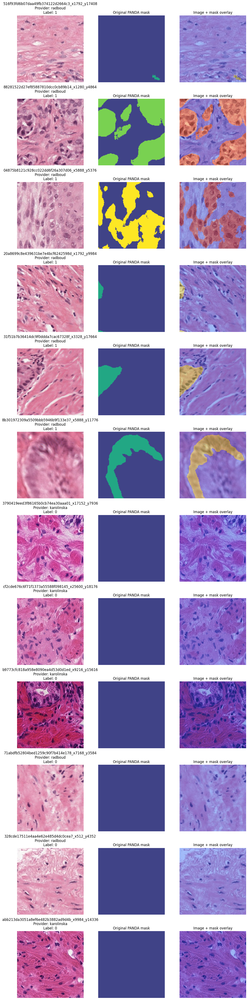

In [94]:

# VISUAL QC — IMAGE + MASK PAIRS


import matplotlib.pyplot as plt
import cv2
import numpy as np

# Pick 6 tumor tiles and 6 non-tumor tiles
tumor_examples = tiles_df[
    tiles_df["tile_label"] == 1
].sample(
    min(6, (tiles_df["tile_label"] == 1).sum()),
    random_state=42
)

non_tumor_examples = tiles_df[
    tiles_df["tile_label"] == 0
].sample(
    min(6, (tiles_df["tile_label"] == 0).sum()),
    random_state=42
)

examples = pd.concat([
    tumor_examples,
    non_tumor_examples
]).reset_index(drop=True)


fig, axes = plt.subplots(
    len(examples),
    3,
    figsize=(12, 4 * len(examples))
)

if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)


for i, (_, row) in enumerate(examples.iterrows()):


    # Read image
    

    image = cv2.imread(
        row["image_path"]
    )

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    
    # Read mask
    

    mask = cv2.imread(
        row["mask_path"],
        cv2.IMREAD_UNCHANGED
    )

    
    # Display image
    

    axes[i, 0].imshow(image)
    axes[i, 0].set_title(
        f"{row['tile_id']}\n"
        f"Provider: {row['data_provider']}\n"
        f"Label: {row['tile_label']}"
    )
    axes[i, 0].axis("off")

    
    # Display mask
    

    axes[i, 1].imshow(
        mask,
        cmap="viridis",
        vmin=0,
        vmax=5
    )

    axes[i, 1].set_title(
        "Original PANDA mask"
    )
    axes[i, 1].axis("off")

    
    # Overlay
    

    axes[i, 2].imshow(image)
    axes[i, 2].imshow(
        mask,
        cmap="jet",
        alpha=0.35,
        vmin=0,
        vmax=5
    )

    axes[i, 2].set_title(
        "Image + mask overlay"
    )
    axes[i, 2].axis("off")


plt.tight_layout()
plt.show()

In [95]:
# =========================================================
# FINALIZE tiles.csv
# =========================================================

tiles_final = tiles_df.copy()

# Portable relative paths
tiles_final["image_path"] = tiles_final["image_path"].apply(
    lambda p: str(Path(p).relative_to(OUTPUT_DIR))
)

tiles_final["mask_path"] = tiles_final["mask_path"].apply(
    lambda p: str(Path(p).relative_to(OUTPUT_DIR))
)

# Save CSV
tiles_csv_path = OUTPUT_DIR / "tiles.csv"

tiles_final.to_csv(
    tiles_csv_path,
    index=False
)

print("Saved:", tiles_csv_path)
print("Rows:", len(tiles_final))
print("Columns:", len(tiles_final.columns))

display(tiles_final.head())

Saved: /kaggle/working/pathoscope_tiles/tiles.csv
Rows: 12800
Columns: 13


,tile_id,image_id,data_provider,x,y,tile_size,tissue_fraction,tile_label,isup_grade,gleason_score,mask_available,image_path,mask_path
0,8f264374ed3fa427615c1650218e7f21_x1536_y1536,8f264374ed3fa427615c1650218e7f21,radboud,1536,1536,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x1536_...,masks/8f264374ed3fa427615c1650218e7f21_x1536_y...
1,8f264374ed3fa427615c1650218e7f21_x1792_y4864,8f264374ed3fa427615c1650218e7f21,radboud,1792,4864,256,1.0,1,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x1792_...,masks/8f264374ed3fa427615c1650218e7f21_x1792_y...
2,8f264374ed3fa427615c1650218e7f21_x2560_y7936,8f264374ed3fa427615c1650218e7f21,radboud,2560,7936,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2560_...,masks/8f264374ed3fa427615c1650218e7f21_x2560_y...
3,8f264374ed3fa427615c1650218e7f21_x2048_y8448,8f264374ed3fa427615c1650218e7f21,radboud,2048,8448,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2048_...,masks/8f264374ed3fa427615c1650218e7f21_x2048_y...
4,8f264374ed3fa427615c1650218e7f21_x2560_y8448,8f264374ed3fa427615c1650218e7f21,radboud,2560,8448,256,1.0,0,1,3+3,1,images/8f264374ed3fa427615c1650218e7f21_x2560_...,masks/8f264374ed3fa427615c1650218e7f21_x2560_y...


In [96]:
# =========================================================
# CREATE ZIP FILES
# =========================================================

import zipfile
from pathlib import Path

IMG_ZIP = OUTPUT_DIR / "tiles_img.zip"
MASK_ZIP = OUTPUT_DIR / "tiles_mask.zip"


def create_zip(source_dir, output_zip):
    files = list(source_dir.rglob("*"))
    files = [p for p in files if p.is_file()]

    print(f"\nCreating {output_zip.name}")
    print("Files:", len(files))

    with zipfile.ZipFile(
        output_zip,
        mode="w",
        compression=zipfile.ZIP_DEFLATED
    ) as z:

        for file_path in tqdm(
            files,
            desc=output_zip.name
        ):
            z.write(
                file_path,
                arcname=file_path.relative_to(source_dir)
            )

    print(
        "Created:",
        output_zip,
        f"({output_zip.stat().st_size / (1024**2):.2f} MB)"
    )


create_zip(
    IMG_DIR,
    IMG_ZIP
)

create_zip(
    MASK_DIR,
    MASK_ZIP
)


Creating tiles_img.zip
Files: 12928


tiles_img.zip:   0%|          | 0/12928 [00:00<?, ?it/s]

Created: /kaggle/working/pathoscope_tiles/tiles_img.zip (342.54 MB)

Creating tiles_mask.zip
Files: 12928


tiles_mask.zip:   0%|          | 0/12928 [00:00<?, ?it/s]

Created: /kaggle/working/pathoscope_tiles/tiles_mask.zip (6.28 MB)


In [97]:
# =========================================================
# FINAL NOTEBOOK 01 OUTPUT CHECK
# =========================================================

print("=" * 60)
print("PATHOSCOPE NOTEBOOK 01 — FINAL OUTPUTS")
print("=" * 60)

for path in [
    tiles_csv_path,
    IMG_ZIP,
    MASK_ZIP
]:

    print(
        f"\n{path.name}"
        f"\nExists: {path.exists()}"
        f"\nSize: {path.stat().st_size / (1024**2):.2f} MB"
        if path.exists()
        else f"\n{path.name}\nExists: False"
    )

PATHOSCOPE NOTEBOOK 01 — FINAL OUTPUTS

tiles.csv
Exists: True
Size: 2.85 MB

tiles_img.zip
Exists: True
Size: 342.54 MB

tiles_mask.zip
Exists: True
Size: 6.28 MB


In [98]:
# =========================================================
# ZIP INTEGRITY + CONTENT INSPECTION
# =========================================================

import zipfile
from collections import Counter

for zip_path in [IMG_ZIP, MASK_ZIP]:

    print("\n" + "=" * 60)
    print("Checking:", zip_path.name)
    print("=" * 60)

    with zipfile.ZipFile(zip_path, "r") as z:

        all_entries = z.namelist()

        # Actual files only
        files = [
            name
            for name in all_entries
            if not name.endswith("/")
        ]

        directories = [
            name
            for name in all_entries
            if name.endswith("/")
        ]

        bad_file = z.testzip()

        print("Total ZIP entries:", len(all_entries))
        print("Directory entries:", len(directories))
        print("Actual files:", len(files))
        print("Corrupt file:", bad_file)

        # File extensions
        extensions = Counter(
            Path(name).suffix.lower()
            for name in files
        )

        print("\nFile types:")
        for ext, count in extensions.items():
            print(f"{ext}: {count}")

        print("\nFirst 5 entries:")
        for name in all_entries[:5]:
            print(name)

        print("\nLast 5 entries:")
        for name in all_entries[-5:]:
            print(name)

        if bad_file is None:
            print("\n ZIP corruption check PASSED")
        else:
            print(
                "\n Corrupt file found:",
                bad_file
            )


Checking: tiles_img.zip
Total ZIP entries: 12928
Directory entries: 0
Actual files: 12928
Corrupt file: None

File types:
.jpg: 12928

First 5 entries:
e3cf7905ba04ebe9a090b586b4988e3d_x19968_y4352.jpg
735ed10b9f870ff45482454f55b1d807_x5376_y7424.jpg
fa6f7b3a6e9c17919d127c670423774e_x19712_y13568.jpg
8369d7bac658189235a5d774d6ee5f71_x46848_y5888.jpg
932c710132acaf350cbc949b53417207_x3328_y6656.jpg

Last 5 entries:
bc763ec4c8db4a23ae6c074bcf20e00b_x13312_y8192.jpg
e05f477f1d1693f8b4a5e629bb0745b2_x10496_y7936.jpg
08e90c44bcfe29aa64beff429f94e291_x8704_y5632.jpg
b3852036b9bab5f90891f5f18617b559_x7680_y6400.jpg
fa6f7b3a6e9c17919d127c670423774e_x19712_y14080.jpg

 ZIP corruption check PASSED

Checking: tiles_mask.zip
Total ZIP entries: 12928
Directory entries: 0
Actual files: 12928
Corrupt file: None

File types:
.png: 12928

First 5 entries:
c8ca4858e14ad4bc1a466796f147f1ca_x6656_y9216.png
0f1ea91c9f917bb3d198f02fd432e4ce_x1280_y1024.png
f815e7ebafbbfa2578e3abadc8a5d15b_x10752_y1792.png


In [99]:
# =========================================================
# CHECK DISK CONTENT VS tiles.csv
# =========================================================

image_files = {
    p.name
    for p in IMG_DIR.glob("*.jpg")
}

mask_files = {
    p.name
    for p in MASK_DIR.glob("*.png")
}

csv_image_files = {
    Path(p).name
    for p in tiles_final["image_path"]
}

csv_mask_files = {
    Path(p).name
    for p in tiles_final["mask_path"]
}

print("Images on disk:", len(image_files))
print("Images in CSV:", len(csv_image_files))

print("Masks on disk:", len(mask_files))
print("Masks in CSV:", len(csv_mask_files))

print("\nExtra images on disk:",
      len(image_files - csv_image_files))

print("Missing images from disk:",
      len(csv_image_files - image_files))

print("\nExtra masks on disk:",
      len(mask_files - csv_mask_files))

print("Missing masks from disk:",
      len(csv_mask_files - mask_files))

Images on disk: 12928
Images in CSV: 12800
Masks on disk: 12928
Masks in CSV: 12800

Extra images on disk: 128
Missing images from disk: 0

Extra masks on disk: 128
Missing masks from disk: 0


In [100]:
# =========================================================
# REMOVE STALE FILES
# =========================================================

extra_images = image_files - csv_image_files
extra_masks = mask_files - csv_mask_files

print("Extra images to remove:", len(extra_images))
print("Extra masks to remove:", len(extra_masks))

for filename in extra_images:
    (IMG_DIR / filename).unlink()

for filename in extra_masks:
    (MASK_DIR / filename).unlink()

print("\nCleanup complete.")

Extra images to remove: 128
Extra masks to remove: 128

Cleanup complete.


In [101]:
print(
    "Images on disk:",
    len(list(IMG_DIR.glob("*.jpg")))
)

print(
    "Masks on disk:",
    len(list(MASK_DIR.glob("*.png")))
)

print(
    "Images in CSV:",
    len(csv_image_files)
)

print(
    "Masks in CSV:",
    len(csv_mask_files)
)

Images on disk: 12800
Masks on disk: 12800
Images in CSV: 12800
Masks in CSV: 12800


In [102]:
# Recreate clean ZIPs

if IMG_ZIP.exists():
    IMG_ZIP.unlink()

if MASK_ZIP.exists():
    MASK_ZIP.unlink()

create_zip(IMG_DIR, IMG_ZIP)
create_zip(MASK_DIR, MASK_ZIP)


Creating tiles_img.zip
Files: 12800


tiles_img.zip:   0%|          | 0/12800 [00:00<?, ?it/s]

Created: /kaggle/working/pathoscope_tiles/tiles_img.zip (339.33 MB)

Creating tiles_mask.zip
Files: 12800


tiles_mask.zip:   0%|          | 0/12800 [00:00<?, ?it/s]

Created: /kaggle/working/pathoscope_tiles/tiles_mask.zip (6.17 MB)


In [103]:
# Final integrity check

for zip_path, expected_count, extension in [
    (IMG_ZIP, 12800, ".jpg"),
    (MASK_ZIP, 12800, ".png")
]:

    print("\n" + "=" * 60)
    print(zip_path.name)
    print("=" * 60)

    with zipfile.ZipFile(zip_path, "r") as z:

        files = [
            name
            for name in z.namelist()
            if not name.endswith("/")
        ]

        bad_file = z.testzip()

        print("Files:", len(files))
        print("Expected:", expected_count)
        print("Corrupt file:", bad_file)

        wrong_extension = [
            name for name in files
            if Path(name).suffix.lower() != extension
        ]

        print("Wrong extension:", len(wrong_extension))

        assert len(files) == expected_count
        assert bad_file is None
        assert len(wrong_extension) == 0

    print(" FINAL ZIP CHECK PASSED")


tiles_img.zip
Files: 12800
Expected: 12800
Corrupt file: None
Wrong extension: 0
 FINAL ZIP CHECK PASSED

tiles_mask.zip
Files: 12800
Expected: 12800
Corrupt file: None
Wrong extension: 0
 FINAL ZIP CHECK PASSED
